## Task 1-DBSCAN on Mall Customers

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

np.random.seed(42)

mall_data = pd.DataFrame({
    "Income_k": np.concatenate([
        np.random.normal(40, 7, 60),
        np.random.normal(80, 8, 70),
        np.random.normal(125, 9, 60),
        [15, 180, 190, 200]
    ]),
    "SpendScore": np.concatenate([
        np.random.normal(30, 8, 60),
        np.random.normal(55, 9, 70),
        np.random.normal(75, 8, 60),
        [5, 5, 98, 2]
    ])
})

X = mall_data[["Income_k", "SpendScore"]]
X_scaled = StandardScaler().fit_transform(X)

db = DBSCAN(eps=0.28, min_samples=5)
labels = db.fit_predict(X_scaled)

mall_data["Cluster"] = labels

clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
noise_points = np.sum(labels == -1)

print("=== DBSCAN Summary ===")
print("Clusters detected:", clusters_found)
print("Noise points:", noise_points)


=== DBSCAN Summary ===
Clusters detected: 3
Noise points: 9


## Task 2- Visualizing DBSCAN Results

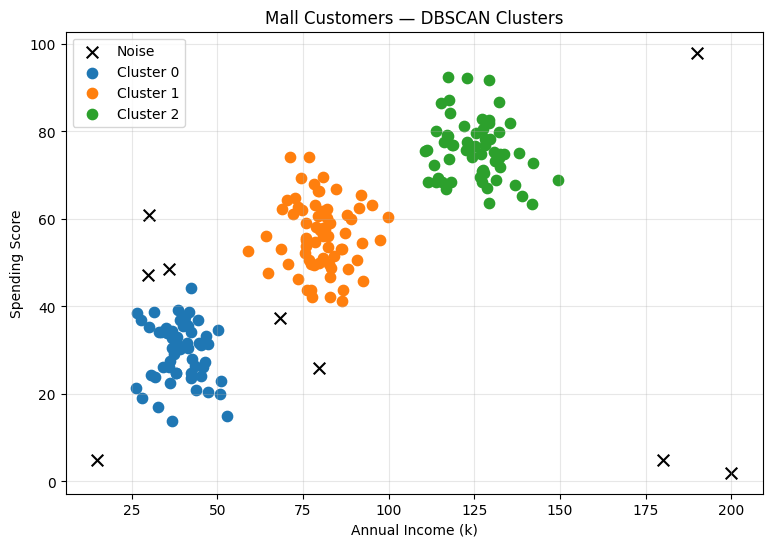

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))
for cluster_id in sorted(set(labels)):
    mask = labels == cluster_id
    if cluster_id == -1:
        plt.scatter(X[mask]["Income_k"], X[mask]["SpendScore"],
                    c="black", marker="x", s=70, label="Noise")
    else:
        plt.scatter(X[mask]["Income_k"], X[mask]["SpendScore"],
                    s=55, label=f"Cluster {cluster_id}")
plt.xlabel("Annual Income (k)")
plt.ylabel("Spending Score")
plt.title("Mall Customers — DBSCAN Clusters")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Task 3- Parameter Sensitivity

In [3]:
param_list = [(0.20,5),(0.28,5),(0.40,5),(0.28,8)]
results = []

for eps, min_pts in param_list:
    model = DBSCAN(eps=eps, min_samples=min_pts)
    lbls = model.fit_predict(X_scaled)
    clusters = len(set(lbls)) - (1 if -1 in lbls else 0)
    noise = np.sum(lbls == -1)
    results.append({"eps":eps,"min_samples":min_pts,"clusters":clusters,"noise":noise})

print(pd.DataFrame(results))


    eps  min_samples  clusters  noise
0  0.20            5         3     27
1  0.28            5         3      9
2  0.40            5         3      6
3  0.28            8         3     14


## Task 4- DBSCAN vs K-Means

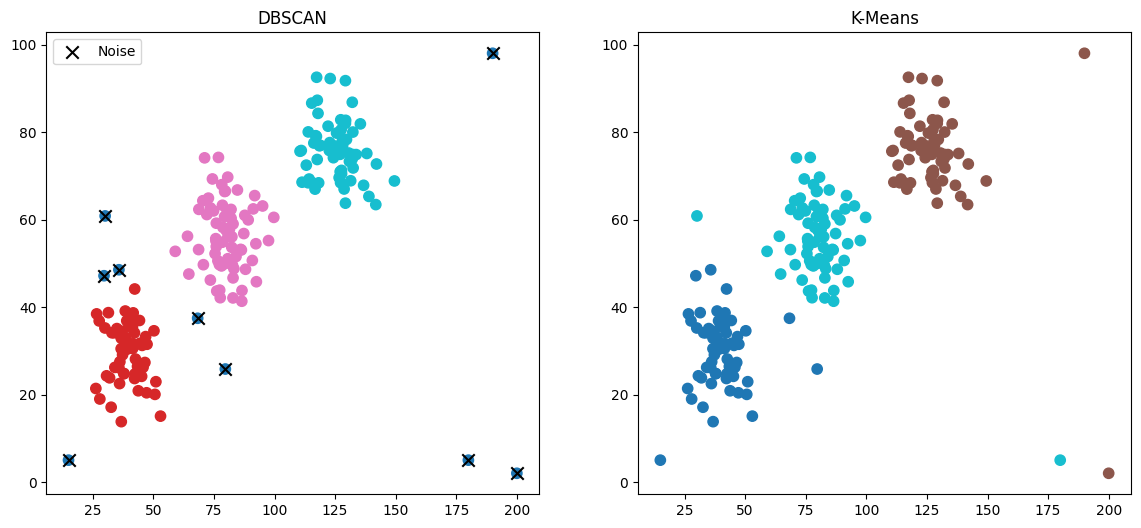

Clusters used for K-Means: 3


In [4]:
from sklearn.cluster import KMeans

dbscan_model = DBSCAN(eps=0.28, min_samples=5)
db_labels = dbscan_model.fit_predict(X_scaled)
db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)

kmeans_model = KMeans(n_clusters=db_clusters, random_state=42, n_init=10)
km_labels = kmeans_model.fit_predict(X_scaled)

fig, ax = plt.subplots(1,2,figsize=(14,6))

ax[0].scatter(X["Income_k"], X["SpendScore"], c=db_labels, cmap="tab10", s=55)
ax[0].scatter(X.loc[db_labels==-1,"Income_k"], X.loc[db_labels==-1,"SpendScore"],
              c="black", marker="x", s=80, label="Noise")
ax[0].set_title("DBSCAN")
ax[0].legend()

ax[1].scatter(X["Income_k"], X["SpendScore"], c=km_labels, cmap="tab10", s=55)
ax[1].set_title("K-Means")

plt.show()
print("Clusters used for K-Means:", db_clusters)


## Task 5- DBSCAN on Non-Spherical Data

=== Make Moons DBSCAN ===
Clusters: 2
Noise points: 0


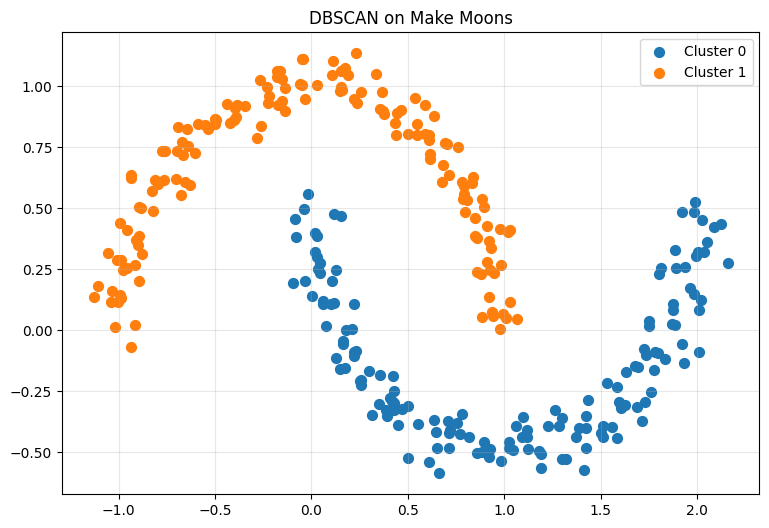

In [5]:
from sklearn.datasets import make_moons

X_moon, y_moon = make_moons(n_samples=300, noise=0.06, random_state=42)

moon_db = DBSCAN(eps=0.18, min_samples=5)
moon_labels = moon_db.fit_predict(X_moon)

moon_clusters = len(set(moon_labels)) - (1 if -1 in moon_labels else 0)
moon_noise = np.sum(moon_labels == -1)

print("=== Make Moons DBSCAN ===")
print("Clusters:", moon_clusters)
print("Noise points:", moon_noise)

plt.figure(figsize=(9,6))
for cid in sorted(set(moon_labels)):
    mask = moon_labels == cid
    if cid == -1:
        plt.scatter(X_moon[mask,0], X_moon[mask,1], c="black", marker="x", s=70, label="Noise")
    else:
        plt.scatter(X_moon[mask,0], X_moon[mask,1], s=50, label=f"Cluster {cid}")
plt.title("DBSCAN on Make Moons")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
